KGAT_e07e9b6a9acd30550143be2f791db91d

In [2]:
import kagglehub

path = kagglehub.dataset_download("wengmhu/fdm-3d-printing-defect-dataset")

print("Path to dataset files:", path)

100%|██████████| 5.85G/5.85G [04:20<00:00, 24.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/wengmhu/fdm-3d-printing-defect-dataset/versions/1


In [3]:
import os
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory

  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [4]:
walk_through_dir(path);

There are 1 directories and 0 images in '/root/.cache/kagglehub/datasets/wengmhu/fdm-3d-printing-defect-dataset/versions/1'.
There are 1 directories and 0 images in '/root/.cache/kagglehub/datasets/wengmhu/fdm-3d-printing-defect-dataset/versions/1/FDM-3D-Printing-Defect-Dataset'.
There are 5 directories and 0 images in '/root/.cache/kagglehub/datasets/wengmhu/fdm-3d-printing-defect-dataset/versions/1/FDM-3D-Printing-Defect-Dataset/data'.
There are 0 directories and 91 images in '/root/.cache/kagglehub/datasets/wengmhu/fdm-3d-printing-defect-dataset/versions/1/FDM-3D-Printing-Defect-Dataset/data/Off_platform'.
There are 0 directories and 364 images in '/root/.cache/kagglehub/datasets/wengmhu/fdm-3d-printing-defect-dataset/versions/1/FDM-3D-Printing-Defect-Dataset/data/Layer_shifting'.
There are 0 directories and 472 images in '/root/.cache/kagglehub/datasets/wengmhu/fdm-3d-printing-defect-dataset/versions/1/FDM-3D-Printing-Defect-Dataset/data/Cracking'.
There are 0 directories and 538 i

## Define Data Paths and Create Directories


In [5]:
import os

# 1. Define data_dir pointing to the main data directory within the downloaded dataset
data_dir = os.path.join(path, 'FDM-3D-Printing-Defect-Dataset', 'data')
print(f"Base data directory: {data_dir}")

# 2. Create train_dir and test_dir
train_dir = './train'
test_dir = './test'
print(f"Train directory: {train_dir}")
print(f"Test directory: {test_dir}")

# 3. Define a list of the 5 defect class names
defect_classes = ['Layer_shifting', 'Off_platform', 'Warping', 'Stringing', 'Cracking']
print(f"Defect classes: {defect_classes}")

# 5. Use os.makedirs() to create the train_dir and test_dir
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)
print(f"Created main directories: {train_dir} and {test_dir}")

# 6. For each defect class, create a corresponding subdirectory within train_dir and test_dir
for cls in defect_classes:
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)
    print(f"Created subdirectories for class '{cls}' in train and test.")

Base data directory: /root/.cache/kagglehub/datasets/wengmhu/fdm-3d-printing-defect-dataset/versions/1/FDM-3D-Printing-Defect-Dataset/data
Train directory: ./train
Test directory: ./test
Defect classes: ['Layer_shifting', 'Off_platform', 'Warping', 'Stringing', 'Cracking']
Created main directories: ./train and ./test
Created subdirectories for class 'Layer_shifting' in train and test.
Created subdirectories for class 'Off_platform' in train and test.
Created subdirectories for class 'Warping' in train and test.
Created subdirectories for class 'Stringing' in train and test.
Created subdirectories for class 'Cracking' in train and test.


## Split Data into Train and Test Sets



In [6]:
import glob
import shutil
from sklearn.model_selection import train_test_split
import os

# 3. Iterate through each defect_class in the defect_classes list
for cls in defect_classes:
    # 4. Construct the source directory path
    source_dir = os.path.join(data_dir, cls)

    # 5. Use glob.glob() to get a list of all image file paths
    # Assuming images are either .jpg or .png
    image_paths = glob.glob(os.path.join(source_dir, '*.jpg'))
    image_paths.extend(glob.glob(os.path.join(source_dir, '*.png')))

    print(f"Found {len(image_paths)} images for class '{cls}'.")

    # 6. Split the list of image file paths into training and testing sets
    train_images, test_images = train_test_split(
        image_paths,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    print(f"Splitting '{cls}': {len(train_images)} training images, {len(test_images)} testing images.")

    # 7. For each image in the training set, copy it to the train_dir
    for image_path in train_images:
        dest_path = os.path.join(train_dir, cls, os.path.basename(image_path))
        shutil.copy2(image_path, dest_path) # Changed move to copy2

    # 8. For each image in the testing set, copy it to the test_dir
    for image_path in test_images:
        dest_path = os.path.join(test_dir, cls, os.path.basename(image_path))
        shutil.copy2(image_path, dest_path) # Changed move to copy2

    print(f"Moved images for class '{cls}' to train and test directories.")

print("All images split and moved successfully.")

Found 364 images for class 'Layer_shifting'.
Splitting 'Layer_shifting': 291 training images, 73 testing images.
Moved images for class 'Layer_shifting' to train and test directories.
Found 91 images for class 'Off_platform'.
Splitting 'Off_platform': 72 training images, 19 testing images.
Moved images for class 'Off_platform' to train and test directories.
Found 538 images for class 'Warping'.
Splitting 'Warping': 430 training images, 108 testing images.
Moved images for class 'Warping' to train and test directories.
Found 447 images for class 'Stringing'.
Splitting 'Stringing': 357 training images, 90 testing images.
Moved images for class 'Stringing' to train and test directories.
Found 472 images for class 'Cracking'.
Splitting 'Cracking': 377 training images, 95 testing images.
Moved images for class 'Cracking' to train and test directories.
All images split and moved successfully.


In [7]:
print("Verifying 'train' directory structure:")
walk_through_dir(train_dir)

print("\nVerifying 'test' directory structure:")
walk_through_dir(test_dir)

Verifying 'train' directory structure:
There are 5 directories and 0 images in './train'.
There are 0 directories and 72 images in './train/Off_platform'.
There are 0 directories and 291 images in './train/Layer_shifting'.
There are 0 directories and 377 images in './train/Cracking'.
There are 0 directories and 430 images in './train/Warping'.
There are 0 directories and 357 images in './train/Stringing'.

Verifying 'test' directory structure:
There are 5 directories and 0 images in './test'.
There are 0 directories and 19 images in './test/Off_platform'.
There are 0 directories and 73 images in './test/Layer_shifting'.
There are 0 directories and 95 images in './test/Cracking'.
There are 0 directories and 108 images in './test/Warping'.
There are 0 directories and 90 images in './test/Stringing'.



  *   **Training Set**:
        *   Layer\_shifting: 291 images
        *   Off\_platform: 72 images
        *   Warping: 430 images
        *   Stringing: 357 images
        *   Cracking: 377 images
  *   **Testing Set**:
        *   Layer\_shifting: 73 images
        *   Off\_platform: 19 images
        *   Warping: 108 images
        *   Stringing: 90 images
        *   Cracking: 95 images



## Loading data



In [8]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [9]:
IMG_SIZE = 128
BATCH_SIZE = 32

# Define transformations for the images
data_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # Resize images to IMG_SIZE x IMG_SIZE
    transforms.ToTensor(), # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize image data
])

# Create PyTorch datasets from the image folders
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=data_transforms
)
test_dataset = datasets.ImageFolder(
    test_dir,
    transform=data_transforms
)

# Create PyTorch DataLoaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True # Shuffle training data
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False # No need to shuffle test data
)

# Get class names from the dataset
class_names = train_dataset.classes
print(f"Class names: {class_names}")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")
print("\nData loading into PyTorch DataLoaders complete.")

Class names: ['Cracking', 'Layer_shifting', 'Off_platform', 'Stringing', 'Warping']
Number of training samples: 1527
Number of testing samples: 385

Data loading into PyTorch DataLoaders complete.


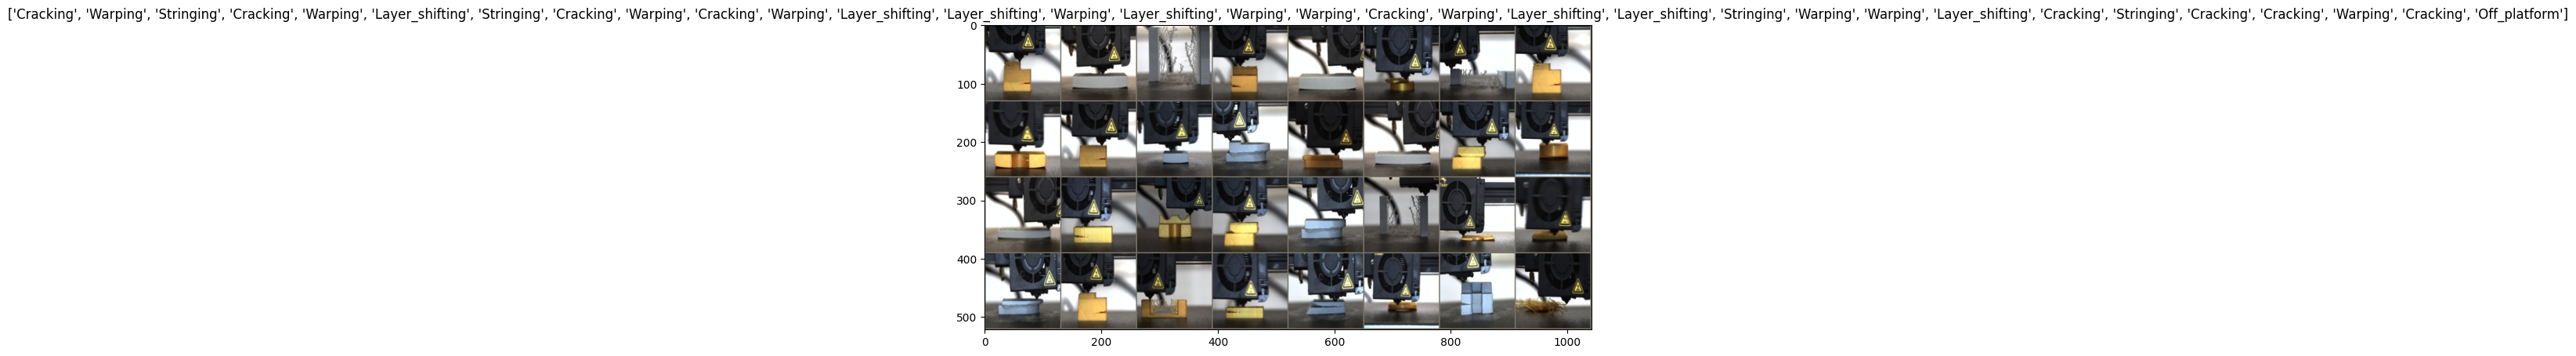

In [10]:
# Function to imshow for PyTorch tensors
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a batch of training data
inputs, labels = next(iter(train_dataloader))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

plt.figure(figsize=(10,10))
imshow(out, title=[class_names[x] for x in labels])
plt.show()

## Define the Model (Device-Agnostic)

In [15]:
import torch.nn as nn
import torch.nn.functional as F

# 1. Determine the device to use (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Define a simple Convolutional Neural Network (CNN)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        # First convolutional layer: 3 input channels (for RGB images), 32 output channels
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        # Max pooling layer to reduce spatial dimensions
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # Second convolutional layer: 32 input channels, 64 output channels
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # Calculate the input features for the first fully connected layer
        # After two pooling layers, image dimensions are reduced by 4 (IMG_SIZE // 2 // 2)
        # The number of channels is 64 from the last conv layer
        self.fc1 = nn.Linear(64 * (IMG_SIZE // 4) * (IMG_SIZE // 4), 128)
        # Second fully connected layer: 128 input features, `num_classes` output features
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Apply first convolution, ReLU activation, and then pooling
        x = self.pool(F.relu(self.conv1(x)))
        # Apply second convolution, ReLU activation, and then pooling
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten the tensor for the fully connected layers
        # -1 infers the batch size, and the rest calculates the total features
        x = x.view(-1, 64 * (IMG_SIZE // 4) * (IMG_SIZE // 4))

        # Apply first fully connected layer with ReLU activation
        x = F.relu(self.fc1(x))
        # Apply second fully connected layer (output layer)
        x = self.fc2(x)
        return x

# 3. Instantiate the model
num_classes = len(class_names)
model = SimpleCNN(num_classes)

# 4. Move the model to the chosen device (GPU or CPU)
model.to(device)

print(f"Model instantiated and moved to {device}:")
print(model)

Using device: cuda
Model instantiated and moved to cuda:
SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=65536, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)


## Define Loss Function and Optimizer

In [16]:
import torch.optim as optim

# Define the loss function (Cross-Entropy Loss is common for classification)
criterion = nn.CrossEntropyLoss()

# Define the optimizer (Adam is a popular choice for deep learning)
# It updates the model's weights based on the calculated loss
optimizer = optim.Adam(model.parameters(), lr=0.001) # Learning rate set to 0.001

print("Loss function (CrossEntropyLoss) and optimizer (Adam) defined.")

Loss function (CrossEntropyLoss) and optimizer (Adam) defined.


## Training and Evaluating the Model

In [17]:
# Number of training cycles (epochs)
num_epochs = 3

print(f"Starting training for {num_epochs} epochs...")

# Loop through each epoch
for epoch in range(num_epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0

    # Iterate over batches of data from the training dataloader
    for i, data in enumerate(train_dataloader, 0):
        # Get inputs (images) and labels (classes) from the current batch
        # Move them to the selected device (GPU/CPU)
        inputs, labels = data[0].to(device), data[1].to(device)

        # Zero the parameter gradients before each backward pass
        # This prevents gradients from accumulating across batches
        optimizer.zero_grad()

        # Forward pass: compute predicted outputs by passing inputs to the model
        outputs = model(inputs)
        # Calculate the loss based on predicted outputs and true labels
        loss = criterion(outputs, labels)
        # Backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # Optimizer step: update model parameters using the computed gradients
        optimizer.step()

        # Accumulate the loss for the current epoch
        running_loss += loss.item()

    # Print training statistics after each epoch
    print(f"Epoch {epoch + 1}/{num_epochs}, Training Loss: {running_loss / len(train_dataloader):.4f}")

    # Evaluate the model on the test set after each epoch
    model.eval() # Set the model to evaluation mode (disables dropout, batchnorm updates, etc.)
    correct = 0
    total = 0
    # Deactivate autograd engine to save memory and computations during inference
    with torch.no_grad():
        # Iterate over batches of data from the test dataloader
        for data in test_dataloader:
            # Get images and labels from the current batch, move to device
            images, labels = data[0].to(device), data[1].to(device)
            # Forward pass to get predictions
            outputs = model(images)
            # Get the predicted class (the one with the highest probability)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0) # Update total number of samples
            correct += (predicted == labels).sum().item() # Update number of correctly predicted samples

    # Calculate and print the accuracy for the current epoch
    accuracy = 100 * correct / total
    print(f"Accuracy on test set after Epoch {epoch + 1}: {accuracy:.2f}%")

print("Finished Training and Evaluation")

Starting training for 3 epochs...
Epoch 1/3, Training Loss: 1.0672
Accuracy on test set after Epoch 1: 94.03%
Epoch 2/3, Training Loss: 0.0670
Accuracy on test set after Epoch 2: 98.44%
Epoch 3/3, Training Loss: 0.0167
Accuracy on test set after Epoch 3: 98.70%
Finished Training and Evaluation


## Make Predictions on 10 Instances

Making predictions for 10 instances:


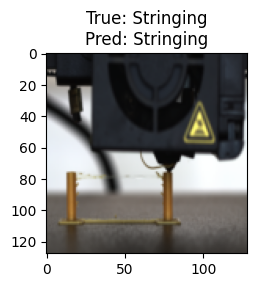

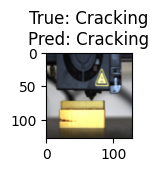

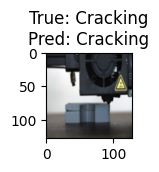

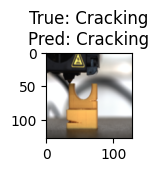

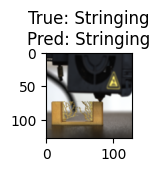

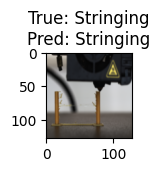

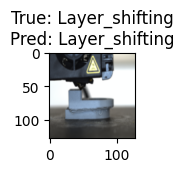

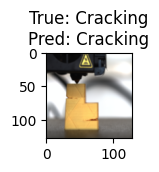

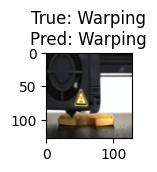

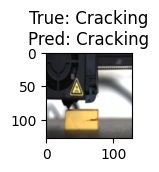

<Figure size 640x480 with 0 Axes>

Predictions complete.


In [18]:
import random

# Set the model to evaluation mode
model.eval()

# Get 10 random indices from the test dataset
num_samples_to_predict = 10
random_indices = random.sample(range(len(test_dataset)), num_samples_to_predict)

print(f"Making predictions for {num_samples_to_predict} instances:")

# Loop through the selected random indices
plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices):
    # Get a single image and its label from the test dataset
    image, true_label = test_dataset[idx]

    # Move the image to the same device as the model (add a batch dimension)
    input_image = image.unsqueeze(0).to(device)

    # Make a prediction
    with torch.no_grad():
        output = model(input_image)
        _, predicted_label_idx = torch.max(output, 1)

    # Get class names for true and predicted labels
    predicted_class = class_names[predicted_label_idx.item()]
    true_class = class_names[true_label]

    # Display the image and prediction
    ax = plt.subplot(2, 5, i + 1) # Create a 2x5 grid for images
    imshow(image.cpu(), title=f"True: {true_class}\nPred: {predicted_class}")
    ax.set_title(f"True: {true_class}\nPred: {predicted_class}",
                 color=("green" if predicted_class == true_class else "red"))
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Predictions complete.")

## Save the Model

In [19]:
# Define a path to save the model
model_save_path = "simple_cnn_defect_classifier.pth"

# Save the model's state dictionary
torch.save(model.state_dict(), model_save_path)

print(f"Model saved successfully to {model_save_path}")

Model saved successfully to simple_cnn_defect_classifier.pth
